# Mini Project: Numerical Pattern Predictor
**Skill Nexis — Deep Learning Week 1**

This version uses no custom classes or functions. It learns a numerical pattern, compares two learning rates, plots training/validation loss, and evaluates predictions on held-out test data.

In [2]:
# Mini Project: Numerical Pattern Predictor
# Skill Nexis - Deep Learning Week 1

import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [3]:
# 1. Create numerical data: y = 3x + 2 with small noise
x = torch.linspace(-10, 10, 200).reshape(-1, 1)
y = 3 * x + 2 + torch.randn_like(x) * 0.5

In [4]:
# 2. Split data into training, validation, and testing sets
x_train, y_train = x[:140], y[:140]
x_val, y_val = x[140:170], y[140:170]
x_test, y_test = x[170:], y[170:]

In [5]:
# 3. Train using two learning rates
learning_rates = [0.01, 0.001]
results = {}

for lr in learning_rates:
    # Start with simple weight and bias (no class)
    w = torch.randn(1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    train_losses = []
    val_losses = []

    for epoch in range(500):
        # Forward propagation
        prediction = w * x_train + b
        loss = ((prediction - y_train) ** 2).mean()

        # Backpropagation and gradient descent
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()

        # Record training and validation loss
        with torch.no_grad():
            train_losses.append(((w * x_train + b - y_train) ** 2).mean().item())
            val_losses.append(((w * x_val + b - y_val) ** 2).mean().item())

    results[lr] = {
        "w": w.detach().clone(),
        "b": b.detach().clone(),
        "train": train_losses,
        "val": val_losses
    }
    print("Learning rate:", lr)
    print("Weight:", round(w.item(), 3), "Bias:", round(b.item(), 3))
    print("Final validation loss:", round(val_losses[-1], 4))
    print()

Learning rate: 0.01
Weight: 3.006 Bias: 2.064
Final validation loss: 0.2787

Learning rate: 0.001
Weight: 2.848 Bias: 0.756
Final validation loss: 4.5012



In [6]:
# 4. Choose the learning rate with the lowest validation loss
best_lr = min(learning_rates, key=lambda rate: results[rate]["val"][-1])
w = results[best_lr]["w"]
b = results[best_lr]["b"]
print("Best learning rate:", best_lr)

Best learning rate: 0.01


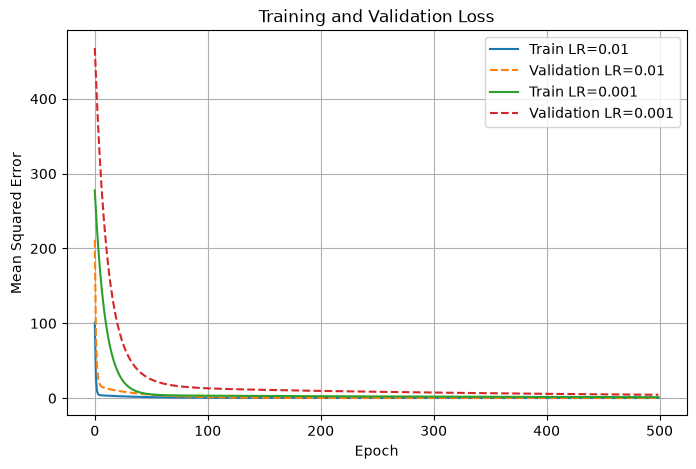

In [7]:
# 5. Plot training and validation loss
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(results[lr]["train"], label=f"Train LR={lr}")
    plt.plot(results[lr]["val"], linestyle="--", label=f"Validation LR={lr}")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Test loss: 0.2397


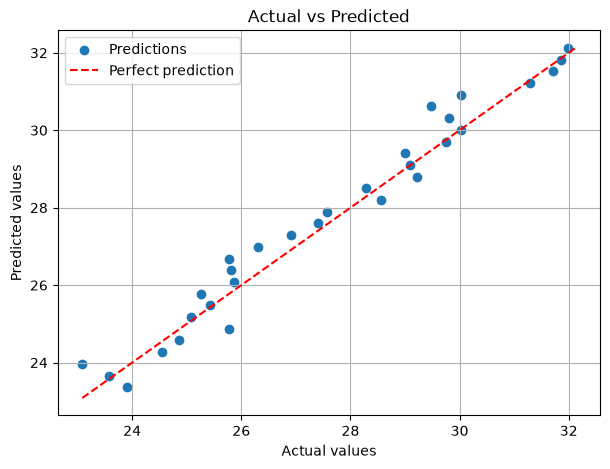

In [8]:
# 6. Test on unseen data and plot actual vs predicted
with torch.no_grad():
    y_pred = w * x_test + b
    test_loss = ((y_pred - y_test) ** 2).mean().item()

print("Test loss:", round(test_loss, 4))
plt.figure(figsize=(7, 5))
plt.scatter(y_test.numpy(), y_pred.numpy(), label="Predictions")
low = min(y_test.min().item(), y_pred.min().item())
high = max(y_test.max().item(), y_pred.max().item())
plt.plot([low, high], [low, high], "r--", label="Perfect prediction")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# 7. Predict a new input
new_x = torch.tensor([[4.0]])
with torch.no_grad():
    new_y = w * new_x + b
print("Prediction for x=4:", round(new_y.item(), 2))

Prediction for x=4: 14.09


In [10]:
# Print Actual vs Predicted Values
with torch.no_grad():
    predicted = w * x_test + b

print("\nActual vs Predicted Values")
print("--------------------------")
for i in range(len(x_test)):
    print("Input:", round(x_test[i].item(), 2),
          "Actual:", round(y_test[i].item(), 2),
          "Predicted:", round(predicted[i].item(), 2))


Actual vs Predicted Values
--------------------------
Input: 7.09 Actual: 23.9 Predicted: 23.36
Input: 7.19 Actual: 23.58 Predicted: 23.66
Input: 7.29 Actual: 23.09 Predicted: 23.97
Input: 7.39 Actual: 24.54 Predicted: 24.27
Input: 7.49 Actual: 24.85 Predicted: 24.57
Input: 7.59 Actual: 25.78 Predicted: 24.87
Input: 7.69 Actual: 25.08 Predicted: 25.18
Input: 7.79 Actual: 25.43 Predicted: 25.48
Input: 7.89 Actual: 25.27 Predicted: 25.78
Input: 7.99 Actual: 25.87 Predicted: 26.08
Input: 8.09 Actual: 25.81 Predicted: 26.38
Input: 8.19 Actual: 25.78 Predicted: 26.69
Input: 8.29 Actual: 26.31 Predicted: 26.99
Input: 8.39 Actual: 26.91 Predicted: 27.29
Input: 8.49 Actual: 27.4 Predicted: 27.59
Input: 8.59 Actual: 27.57 Predicted: 27.89
Input: 8.69 Actual: 28.55 Predicted: 28.2
Input: 8.79 Actual: 28.29 Predicted: 28.5
Input: 8.89 Actual: 29.21 Predicted: 28.8
Input: 8.99 Actual: 29.09 Predicted: 29.1
Input: 9.1 Actual: 29.0 Predicted: 29.4
Input: 9.2 Actual: 29.75 Predicted: 29.71
Input: 9.

In [11]:
# Short Summary
print("\nPROJECT SUMMARY")
print("This project predicts numerical values using PyTorch.")
print("The model learns the pattern y = 3x + 2.")
print("Actual values are compared with predicted values.")
print("Lower prediction error indicates better performance.")


PROJECT SUMMARY
This project predicts numerical values using PyTorch.
The model learns the pattern y = 3x + 2.
Actual values are compared with predicted values.
Lower prediction error indicates better performance.
